In [37]:
import wandb
import pandas as pd

api = wandb.Api()
run = api.run("leo085/MoCA-Long-iWatch-FT/cdvp4abb")

# Use scan_history to fetch all steps
rows = []
for row in run.scan_history():
    rows.append(row)

chap_random_hip = pd.DataFrame(rows)

print(chap_random_hip.shape)   # should now be full length, not capped at 500
# chap_random_hip = chap_random_hip[["_step", "perf/bal_acc", "perf/test_loss"]]

(12921, 16)


In [38]:
import wandb
import pandas as pd

api = wandb.Api()
run = api.run("/leo085/MoCA-Long-iWatch-FT/runs/p5or8b5t")

# Use scan_history to fetch all steps
rows = []
for row in run.scan_history():
    rows.append(row)

chap_ft_hip = pd.DataFrame(rows)

print(chap_ft_hip.shape)   # should now be full length, not capped at 500
# chap_ft_hip = chap_ft_hip[["_step", "perf/bal_acc", "perf/test_loss"]]

(12921, 16)


In [43]:
import matplotlib.pyplot as plt

def plot_chap_nature(df_ft, df_random,
                     label_ft="CHAP Fine-Tuned",
                     label_random="CHAP Random Init",
                     save_path=None):
    """
    Nature-style plot for CHAP models with epoch inferred from row index.
    Assumes 40 valid epochs in both fine-tuned and randomly initialized runs.
    """

    # Filter and index
    df_ft = df_ft[["perf/bal_acc", "perf/test_loss"]].dropna().reset_index(drop=True)
    df_random = df_random[["perf/bal_acc", "perf/test_loss"]].dropna().reset_index(drop=True)

    df_ft["epoch"] = range(len(df_ft))
    df_random["epoch"] = range(len(df_random))

    assert len(df_ft) == len(df_random) == 40, "Expected 40 epochs per run"

    # Nature-style font and line settings
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "STIX Two Text", "Times"],
        "font.size": 9,
        "axes.labelsize": 9,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "axes.linewidth": 0.5,
        "lines.linewidth": 1.0,
        "legend.frameon": False,
        "savefig.dpi": 300
    })

    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2))  # ~178mm × 81mm

    color_ft = "#0072B2"
    color_random = "#D55E00"

    # Plot panel a: Balanced Accuracy
    axes[0].plot(df_random["epoch"], df_random["perf/bal_acc"],
                 label=label_random, color=color_random)
    axes[0].plot(df_ft["epoch"], df_ft["perf/bal_acc"],
                 label=label_ft, color=color_ft)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Balanced Accuracy")
    axes[0].text(-0.12, 1.05, "a", transform=axes[0].transAxes,
                 fontsize=10, fontweight='bold', va='top', ha='right')

    # Plot panel b: Test Loss
    axes[1].plot(df_random["epoch"], df_random["perf/test_loss"],
                 label=label_random, color=color_random)
    axes[1].plot(df_ft["epoch"], df_ft["perf/test_loss"],
                 label=label_ft, color=color_ft)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Test Loss")
    axes[1].text(-0.12, 1.05, "b", transform=axes[1].transAxes,
                 fontsize=10, fontweight='bold', va='top', ha='right')

    # Clean axes
    for ax in axes:
        ax.tick_params(direction="out", length=3, width=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(False)

    # Place legend inside panel b, top left
    axes[1].legend(loc="upper right", frameon=False, handlelength=1.5)

    plt.tight_layout(w_pad=2)

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", transparent=True)
    else:
        plt.show()


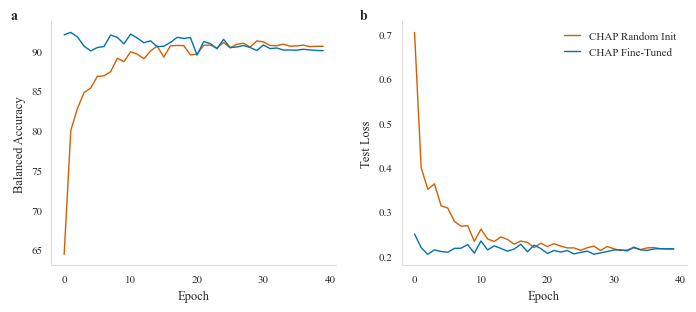

In [44]:
plot_chap_nature(chap_ft_hip, chap_random_hip)

In [45]:
# 
import wandb
import pandas as pd

api = wandb.Api()
run = api.run("/leo085/MoCA-Long-iWatch-FT/runs/7zd1josa")

# Use scan_history to fetch all steps
rows = []
for row in run.scan_history():
    rows.append(row)

chap_random_wrist = pd.DataFrame(rows)


chap_random_wrist = pd.DataFrame(rows)

print(chap_random_wrist.shape)   # should now be full length, not capped at 500
# chap_random_wrist = chap_random_wrist[["_step", "perf/bal_acc", "perf/test_loss"]]

(13321, 16)


In [46]:

# 
import wandb
import pandas as pd

api = wandb.Api()
run = api.run("/leo085/MoCA-Long-iWatch-FT/runs/kmcfojlc")

# Use scan_history to fetch all steps
rows = []
for row in run.scan_history():
    rows.append(row)

chap_ft_wrist = pd.DataFrame(rows)


chap_ft_wrist = pd.DataFrame(rows)

print(chap_ft_wrist.shape)   # should now be full length, not capped at 500
# chap_ft_wrist = chap_ft_wrist[["_step", "perf/bal_acc", "perf/test_loss"]]

(13321, 16)


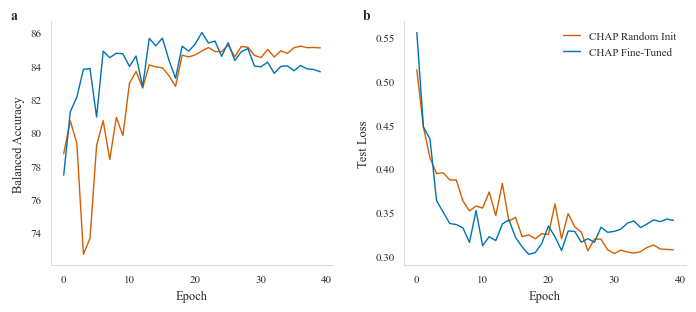

In [47]:
plot_chap_nature(chap_ft_wrist, chap_random_wrist)